# BEATs + uniform filter bank

Тот же split и протокол, что в `supervised_cnn_baseline.ipynb` / `audiomae_finetune_baseline.ipynb`.

STFT → 128 равномерных полос → BEATs_iter3. Pretrained: `checkpoints/BEATs_iter3.pt` (`python scripts/download_beats_pretrained.py`).


In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings(
    "ignore",
    message="`torch.nn.utils.weight_norm` is deprecated*",
    category=FutureWarning,
)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import soundfile as sf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

PROJECT_DIR = Path("/Users/katterns/ITMO/Practice")
if not (PROJECT_DIR / "beats_bat.py").is_file():
    PROJECT_DIR = Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from beats_bat import (
    BEATsBatClassifier,
    build_beats_from_config,
    load_beats_checkpoint,
    waveform_to_beats_fbank,
    DEFAULT_N_FFT,
    DEFAULT_HOP_LENGTH,
)

DATA_DIR = PROJECT_DIR / "cleaned_subset_200"
METADATA_PATH = DATA_DIR / "audio_metadata_cleaned.csv"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BEATS_PRETRAINED = CHECKPOINT_DIR / "BEATs_iter3.pt"
BEST_CKPT = CHECKPOINT_DIR / "beats_bat_finetune_best.pt"
TRAIN_LOG_TXT = CHECKPOINT_DIR / "beats_bat_train_log.txt"

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if hasattr(torch.backends, "cuda") and torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(device)


mps


In [2]:
TARGET_SR = 192_000
CLIP_SEC = 0.5
TARGET_TIME_FRAMES = 256
N_FFT = DEFAULT_N_FFT
HOP_LENGTH = DEFAULT_HOP_LENGTH


def resample_audio(y: np.ndarray, orig_sr: float, target_sr: float) -> np.ndarray:
    if int(orig_sr) == int(target_sr):
        return y.astype(np.float32)
    t_old = np.linspace(0.0, len(y) / orig_sr, num=len(y), endpoint=False)
    t_new = np.linspace(
        0.0,
        len(y) / orig_sr,
        num=int(len(y) * target_sr / orig_sr),
        endpoint=False,
    )
    return np.interp(t_new, t_old, y).astype(np.float32)


def center_crop_or_pad(y: np.ndarray, target_len: int) -> np.ndarray:
    if len(y) >= target_len:
        i0 = (len(y) - target_len) // 2
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


In [3]:
df = pd.read_csv(METADATA_PATH)
assert not df.empty, f"Пустой CSV: {METADATA_PATH}"

species_sorted = sorted(df["species"].unique())
label2id = {s: i for i, s in enumerate(species_sorted)}
id2label = {i: s for s, i in label2id.items()}
n_classes = len(species_sorted)

df["label"] = df["species"].map(label2id)
df["path"] = df.apply(
    lambda r: DATA_DIR / str(r["species"]) / str(r["filename"]),
    axis=1,
)

missing = df[~df["path"].apply(lambda p: p.is_file())]
if len(missing) > 0:
    df = df[df["path"].apply(lambda p: p.is_file())].reset_index(drop=True)

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=df["label"],
)
print(f"train={len(train_df)} val={len(val_df)} classes={n_classes}")


train=4348 val=768 classes=26


In [4]:
class BatWavUniformFbankDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        y, sr = sf.read(str(row["path"]), always_2d=False)
        if y.ndim > 1:
            y = y.mean(axis=-1)
        y = resample_audio(y, float(sr), float(TARGET_SR))
        tgt = int(CLIP_SEC * TARGET_SR)
        y = center_crop_or_pad(y, tgt)
        wav = torch.tensor(y, dtype=torch.float32)
        fbank = waveform_to_beats_fbank(
            wav,
            float(TARGET_SR),
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            target_time_frames=TARGET_TIME_FRAMES,
        )
        return fbank.contiguous().float(), int(row["label"])


train_ds = BatWavUniformFbankDataset(train_df)
val_ds = BatWavUniformFbankDataset(val_df)

BATCH_SIZE = 8
NUM_WORKERS = 0

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=False,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
)


In [5]:
_pretrained_ok = False
if BEATS_PRETRAINED.is_file():
    backbone, beats_cfg = load_beats_checkpoint(BEATS_PRETRAINED, map_location="cpu")
    _pretrained_ok = True
else:
    backbone, beats_cfg = build_beats_from_config()

backbone = backbone.to(device)
classifier = BEATsBatClassifier(
    backbone,
    num_classes=n_classes,
    encoder_dim=beats_cfg.encoder_embed_dim,
).to(device)

BACKBONE_LR = 1e-5 if _pretrained_ok else 5e-4
HEAD_LR = 3e-4
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(
    [
        {"params": classifier.backbone.parameters(), "lr": BACKBONE_LR},
        {"params": classifier.head.parameters(), "lr": HEAD_LR},
    ],
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY,
)
criterion = nn.CrossEntropyLoss()


In [6]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    n = 0
    for x, y in tqdm(loader, desc="train", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        n += x.size(0)
    return total_loss / max(n, 1)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    n = 0
    all_y = []
    all_pred = []
    for x, y in tqdm(loader, desc="val", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        total_loss += loss.item() * x.size(0)
        n += x.size(0)
        pred = logits.argmax(dim=-1)
        all_y.append(y.cpu().numpy())
        all_pred.append(pred.cpu().numpy())
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    return total_loss / max(n, 1), acc, bal, macro_f1, y_true, y_pred


## Resume

Ячейка ниже — если уже есть `beats_bat_finetune_best.pt` (вместо «Первый запуск»).


In [7]:
if not BEST_CKPT.is_file():
    raise FileNotFoundError(BEST_CKPT)

try:
    ckpt_resume = torch.load(BEST_CKPT, map_location="cpu", weights_only=False)
except TypeError:
    ckpt_resume = torch.load(BEST_CKPT, map_location="cpu")

if BEATS_PRETRAINED.is_file():
    backbone, beats_cfg = load_beats_checkpoint(BEATS_PRETRAINED, map_location="cpu")
    _pretrained_ok = True
else:
    backbone, beats_cfg = build_beats_from_config()
    _pretrained_ok = False

backbone = backbone.to(device)
classifier = BEATsBatClassifier(
    backbone,
    num_classes=n_classes,
    encoder_dim=beats_cfg.encoder_embed_dim,
).to(device)
classifier.load_state_dict(ckpt_resume["classifier_state"], strict=True)

cfg = ckpt_resume.get("config") or {}
BACKBONE_LR = cfg.get("backbone_lr", 1e-5 if _pretrained_ok else 5e-4)
HEAD_LR = cfg.get("head_lr", 3e-4)

optimizer = torch.optim.AdamW(
    [
        {"params": classifier.backbone.parameters(), "lr": BACKBONE_LR},
        {"params": classifier.head.parameters(), "lr": HEAD_LR},
    ],
    lr=HEAD_LR,
    weight_decay=1e-4,
)
criterion = nn.CrossEntropyLoss()

END_EPOCH = 40
PATIENCE = 8
last_epoch = int(ckpt_resume.get("epoch", 0))
start_epoch = last_epoch + 1
best_macro_f1 = float(ckpt_resume.get("val_macro_f1", -1.0))
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}

if start_epoch > END_EPOCH:
    raise ValueError(
        f"Чекпоинт epoch={last_epoch}, resume с {start_epoch}, но END_EPOCH={END_EPOCH}. "
        f"Увеличьте END_EPOCH (нужно >= {start_epoch})."
    )
print(f"resume epochs {start_epoch}–{END_EPOCH}, best macro_f1 {best_macro_f1:.4f}")

for epoch in tqdm(range(start_epoch, END_EPOCH + 1), desc="epoch"):
    tr_loss = train_one_epoch(classifier, train_loader, optimizer, criterion)
    val_loss, acc, bal, macro_f1, y_true, y_pred = evaluate(classifier, val_loader)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(acc)
    history["val_macro_f1"].append(macro_f1)

    print(
        f"Epoch {epoch:02d}  loss {tr_loss:.4f}/{val_loss:.4f}  "
        f"acc {acc:.4f}  macro_f1 {macro_f1:.4f}"
    )

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        epochs_no_improve = 0
        torch.save(
            {
                "classifier_state": classifier.state_dict(),
                "label2id": label2id,
                "id2label": {str(k): v for k, v in id2label.items()},
                "config": {
                    "target_sr": TARGET_SR,
                    "clip_sec": CLIP_SEC,
                    "fbank_shape": [TARGET_TIME_FRAMES, 128],
                    "n_fft": N_FFT,
                    "hop_length": HOP_LENGTH,
                    "pretrained_loaded": _pretrained_ok,
                    "backbone_lr": BACKBONE_LR,
                    "head_lr": HEAD_LR,
                },
                "val_macro_f1": macro_f1,
                "val_balanced_acc": bal,
                "epoch": epoch,
            },
            BEST_CKPT,
        )
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping")
            break

print(f"best macro_f1 (val): {best_macro_f1:.4f}")


resume epochs 28–40, best macro_f1 0.6482


epoch:   0%|          | 0/13 [00:00<?, ?it/s]

train:   0%|          | 0/544 [00:00<?, ?it/s]

val:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 28  loss 0.5865/1.5943  acc 0.6250  macro_f1 0.6202


...

val:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 39  loss 0.4481/1.7237  acc 0.6276  macro_f1 0.6227


train:   0%|          | 0/544 [00:00<?, ?it/s]

val:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 40  loss 0.4085/1.8729  acc 0.6133  macro_f1 0.6118
best macro_f1 (val): 0.6520


In [ ]:
MAX_EPOCHS = 40
PATIENCE = 8
best_macro_f1 = -1.0
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}

for epoch in tqdm(range(1, MAX_EPOCHS + 1), desc="epoch"):
    tr_loss = train_one_epoch(classifier, train_loader, optimizer, criterion)
    val_loss, acc, bal, macro_f1, y_true, y_pred = evaluate(classifier, val_loader)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(acc)
    history["val_macro_f1"].append(macro_f1)

    print(
        f"Epoch {epoch:02d}  loss {tr_loss:.4f}/{val_loss:.4f}  "
        f"acc {acc:.4f}  macro_f1 {macro_f1:.4f}"
    )

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        epochs_no_improve = 0
        torch.save(
            {
                "classifier_state": classifier.state_dict(),
                "label2id": label2id,
                "id2label": {str(k): v for k, v in id2label.items()},
                "config": {
                    "target_sr": TARGET_SR,
                    "clip_sec": CLIP_SEC,
                    "fbank_shape": [TARGET_TIME_FRAMES, 128],
                    "n_fft": N_FFT,
                    "hop_length": HOP_LENGTH,
                    "pretrained_loaded": _pretrained_ok,
                    "backbone_lr": BACKBONE_LR,
                    "head_lr": HEAD_LR,
                },
                "val_macro_f1": macro_f1,
                "val_balanced_acc": bal,
                "epoch": epoch,
            },
            BEST_CKPT,
        )
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping")
            break

print(f"best macro_f1 (val): {best_macro_f1:.4f}")


In [9]:
with open(TRAIN_LOG_TXT, "a", encoding="utf-8") as f:
    for i in range(len(history["val_macro_f1"])):
        f.write(
            f"epoch={i+1}  train_loss={history['train_loss'][i]:.4f}  "
            f"val_loss={history['val_loss'][i]:.4f}  "
            f"acc={history['val_acc'][i]:.4f}  "
            f"macro_f1={history['val_macro_f1'][i]:.4f}\n"
        )


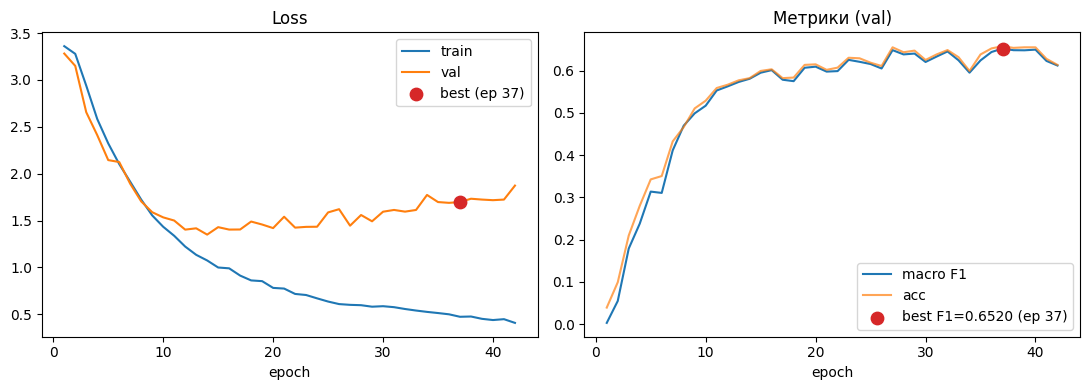

In [12]:
def load_train_log(path: Path) -> pd.DataFrame:
    rows = []
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        row = {}
        for tok in line.split():
            if "=" in tok:
                k, v = tok.split("=", 1)
                row[k] = v
        rows.append(row)
    if not rows:
        raise ValueError(f"Пустой лог: {path}")

    df = pd.DataFrame(rows)
    for col in ("epoch", "train_loss", "val_loss", "acc", "macro_f1", "bal_acc"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["epoch", "macro_f1"]).sort_values("epoch")
    df["epoch"] = df["epoch"].astype(int)
    return df.drop_duplicates("epoch", keep="last").reset_index(drop=True)


log_df = load_train_log(TRAIN_LOG_TXT)
epochs = log_df["epoch"].to_numpy()
best_idx = log_df["macro_f1"].idxmax()
best_ep = int(log_df.loc[best_idx, "epoch"])
best_f1 = float(log_df.loc[best_idx, "macro_f1"])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(epochs, log_df["train_loss"], label="train")
ax[0].plot(epochs, log_df["val_loss"], label="val")
ax[0].scatter(
    [best_ep],
    [log_df.loc[best_idx, "val_loss"]],
    color="C3",
    s=80,
    zorder=5,
    label=f"best (ep {best_ep})",
)
ax[0].set_xlabel("epoch")
ax[0].set_title("Loss")
ax[0].legend()

ax[1].plot(epochs, log_df["macro_f1"], label="macro F1")
ax[1].plot(epochs, log_df["acc"], label="acc", alpha=0.7)
ax[1].scatter(
    [best_ep],
    [best_f1],
    color="C3",
    s=80,
    zorder=5,
    label=f"best F1={best_f1:.4f} (ep {best_ep})",
)
ax[1].set_xlabel("epoch")
ax[1].set_title("Метрики (val)")
ax[1].legend()

plt.tight_layout()
plt.show()


val:   0%|          | 0/96 [00:00<?, ?it/s]

val: acc=0.6576 bal_acc=0.6566 macro_f1=0.6520
              precision    recall  f1-score   support

        ANPA      0.704     0.633     0.667        30
        COTO      0.737     0.560     0.636        25
        EPFU      0.438     0.467     0.452        30
        EUMA      0.853     0.967     0.906        30
        LABL      0.483     0.583     0.528        24
        LABO      0.452     0.467     0.459        30
        LACI      0.667     0.533     0.593        30
        LAIN      0.920     0.767     0.836        30
        LANO      0.600     0.800     0.686        30
        LASE      0.649     0.800     0.716        30
        MYCA      0.579     0.367     0.449        30
        MYCI      0.657     0.767     0.708        30
        MYEV      0.767     0.767     0.767        30
        MYGR      0.750     0.800     0.774        30
        MYLE      0.489     0.733     0.587        30
        MYLU      0.600     0.500     0.545        30
        MYSE      0.593     0.533 

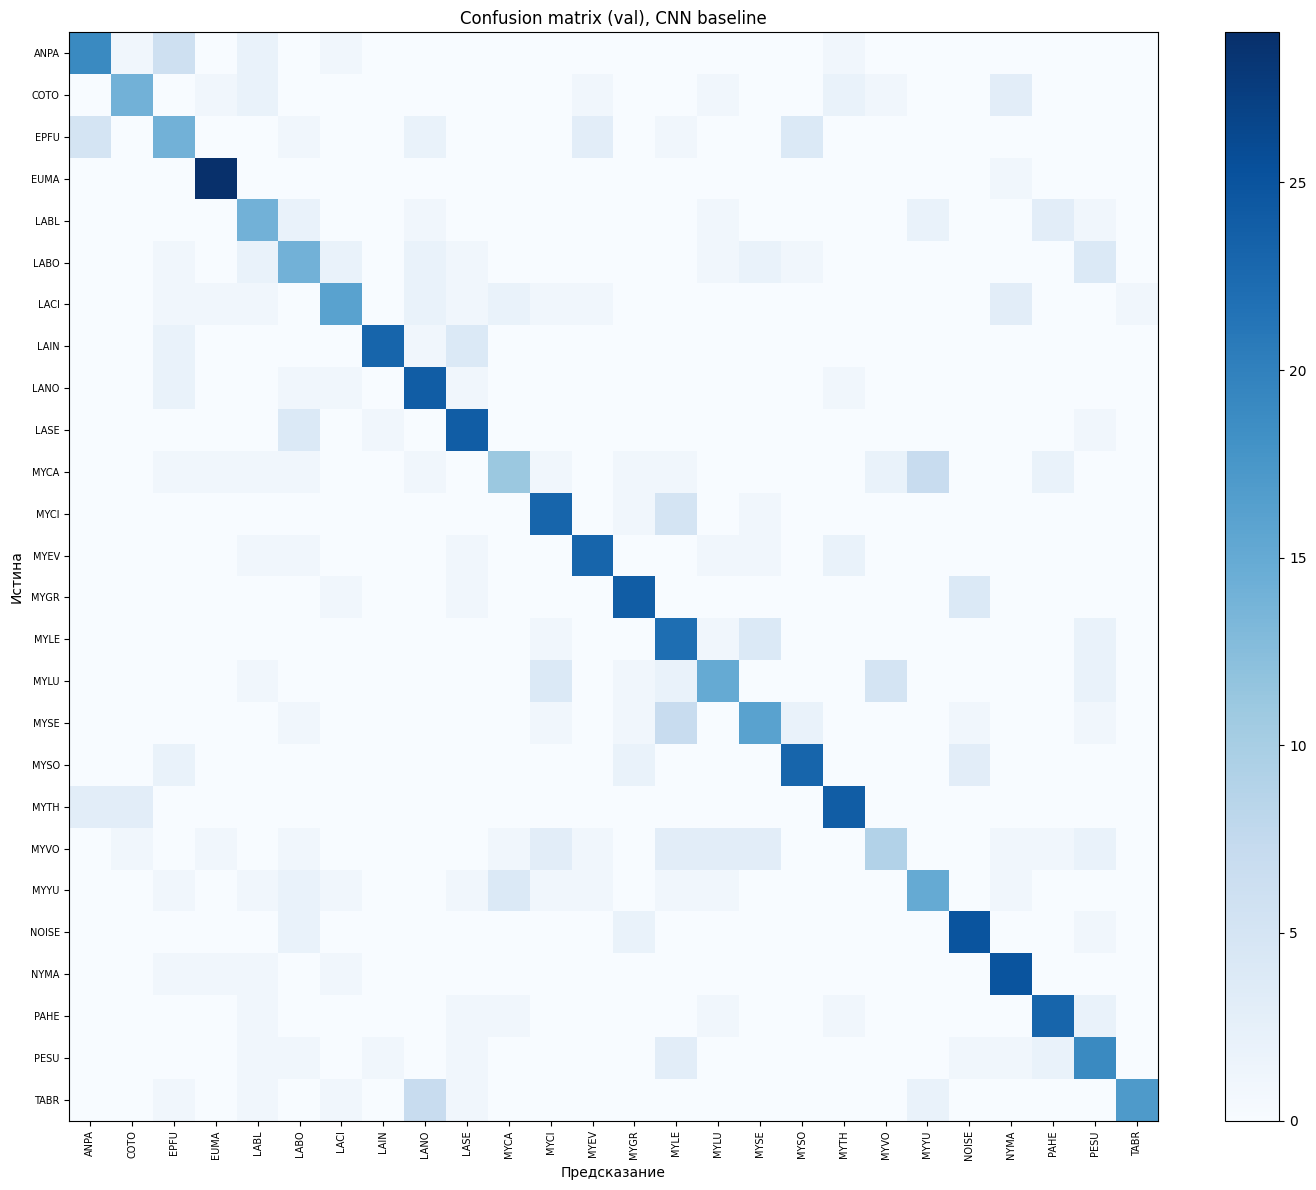

In [ ]:
try:
    ckpt = torch.load(BEST_CKPT, map_location=device, weights_only=False)
except TypeError:
    ckpt = torch.load(BEST_CKPT, map_location=device)
classifier.load_state_dict(ckpt["classifier_state"])

_, acc, bal, macro_f1, y_true, y_pred = evaluate(classifier, val_loader)
labels_order = list(label2id.keys())
print(f"val: acc={acc:.4f} bal_acc={bal:.4f} macro_f1={macro_f1:.4f}")
print(classification_report(y_true, y_pred, target_names=labels_order, digits=3, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(np.arange(n_classes))
ax.set_yticks(np.arange(n_classes))
ax.set_xticklabels(species_sorted, rotation=90, fontsize=7)
ax.set_yticklabels(species_sorted, fontsize=7)
ax.set_ylabel("Истина")
ax.set_xlabel("Предсказание")
ax.set_title("Confusion matrix (val), CNN baseline")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
